In [ ]:
# Initially use 'Drug' subset to set-up code, before running on entire CSD.

In [1]:
from ccdc import io
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

In [2]:
drug_reader = io.EntryReader(subset=io.Subsets.DRUG)

In [3]:
drug_output = Path("all_drug_properties.csv")

def csd_iterator():
    
    for entry in drug_reader:
        try:
            mol = entry.molecule
            smiles = mol.smiles
        except RuntimeError:
         continue
        yield mol.identifier, smiles

def _unused_filter(mol):
    mol_id = mol.identifier
    donors = [a for a in mol.atoms if a.is_donor]
    acceptors = [a for a in mol.atoms if a.is_acceptor]

    n_donors = len(donors)
    n_acceptors = len(acceptors)
    weight = mol.molecular_weight

def run():
    records = []
    for i, (identifier, smiles) in enumerate(csd_iterator()):
        if not smiles:
            continue
        mol = Chem.MolFromSmiles(smiles)

        if not mol:
            continue
        
        logp_crippen = Descriptors.MolLogP(mol)
        mol_weight = Descriptors.ExactMolWt(mol)
        hb_donors = Descriptors.NumHDonors(mol)
        hb_acceptors = Descriptors.NumHAcceptors(mol)

        record = {
            "identifier": identifier,
            "smiles": smiles, 
            "HBD": hb_donors,
            "HBA": hb_acceptors,
            "logP": logp_crippen,
            "MW": mol_weight,
            
        }
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(drug_output)

if __name__ == "__main__":
    run()

[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] Explicit valence for atom # 16 O, 4, is greater than permitted
[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] WARNING: not removing hydrogen atom without neighbors
[13:59:51] Explicit valence for atom # 48 C, 5, is greater than permitted
[13:59:52] WARNING: not removing hydrogen atom without neighbors
[13:59:52] WARNING: not removing hydrogen atom without neighbors
[13:59:52] WARNING: not removing hydrogen atom without neighbors
[13:59:52] WARNING: not removing hydrogen atom without neighbors
[13:59:52] WARNING: not removing hydrogen atom without neighbors
[13:59:52] Explicit valence for atom # 28 C, 5, is greater than permitted
[13:59:52] Explicit valence for atom # 6 C, 5, is greater than 

In [5]:
df = pd.read_csv("all_drug_properties.csv")

In [7]:
df.head()

,Unnamed: 0,identifier,smiles,HBD,HBA,logP,MW
0,0,ABABIQ,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654
1,1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291
2,2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628
3,3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657
4,4,ABAZUB,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310


In [11]:
lipinski_columns = ["Ro5- HBD", "Ro5- HBA", "Ro5- logP", "Ro5- MW"]

thresholds = {"HBD": 5, "HBA": 10, "logP": 5, "MW": 500}

for idx, row in df.iterrows():
    for col, thresh in thresholds.items():
        df.loc[idx, f"{col}_bin"] = int(row[col] <= thresh)

In [12]:
df.head()

,Unnamed: 0,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin
0,0,ABABIQ,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654,1.0,1.0,1.0,0.0
1,1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291,1.0,1.0,1.0,1.0
2,2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628,1.0,1.0,1.0,1.0
3,3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657,1.0,1.0,1.0,1.0
4,4,ABAZUB,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310,1.0,1.0,1.0,0.0


In [13]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

df["bin_sum"] = df[bin_cols].sum(axis=1)

In [14]:
df.head()

,Unnamed: 0,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
0,0,ABABIQ,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654,1.0,1.0,1.0,0.0,3.0
1,1,ABADOY,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291,1.0,1.0,1.0,1.0,4.0
2,2,ABAJAQ,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628,1.0,1.0,1.0,1.0,4.0
3,3,ABAQEB,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657,1.0,1.0,1.0,1.0,4.0
4,4,ABAZUB,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310,1.0,1.0,1.0,0.0,3.0


In [ ]:
# Table shows number of entries satisfying 0, 1, 2, 3, or 4 Ro5 conditions

row_summary = (df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))

row_summary["percent"] = 100 * row_summary["count"] / row_summary["count"].sum()

row_summary["percent"] = row_summary["percent"].round(2)

row_summary

,count,percent
bin_sum,,
4,9912,58.78
3,2782,16.50
2,2363,14.01
1,1540,9.13
0,265,1.57


In [22]:
row_summary["count"].sum() == len(df)

True

In [25]:
# Table shows number of entries satisfying each Ro5 condition

col_summary = df[bin_cols].sum().to_frame(name="count")

col_summary["percent"] = 100 * col_summary["count"] / len(df)

col_summary["percent"] = col_summary["percent"].round(2)

col_summary

,count,percent
HBD_bin,14244.0,84.47
HBA_bin,14133.0,83.82
logP_bin,14775.0,87.62
MW_bin,11108.0,65.88


In [26]:
!pip install venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for venn: filename=venn-0.1.3-py3-none-any.whl size=19800 sha256=903cf9c3698e7891a644f9d84c7263140d92c982e571e472a350fe3f88aef68e
  Stored in directory: c:\users\teaching\appdata\local\pip\cache\wheels\b8\2a\b1\a1ff9ba87eb919daed348de8c17b00024dfef34b35e7002e6c
Successfully built venn


<Figure size 800x800 with 0 Axes>

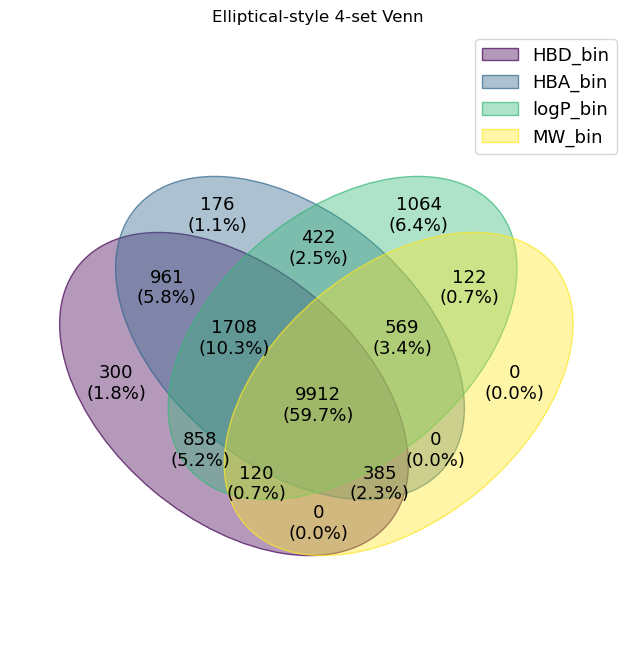

In [29]:
import matplotlib.pyplot as plt
from venn import venn

sets = {c: set(df.index[df[c] == 1]) for c in bin_cols}

plt.figure(figsize=(8, 8))
# use {size} not {count}; {percentage} is percent of the union
v = venn(sets, fmt="{size}\n({percentage:.1f}%)")
plt.title("Elliptical-style 4-set Venn")
plt.show()


In [30]:
!pip install upsetplot

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24914 sha256=5525ecfd752d76f4df493e879079ffa7681bad415380d21f39e61c9ee0191c05
  Stored in directory: c:\users\teaching\appdata\local\pip\cache\wheels\7b\ce\88\1d0bce5b2680165c29c3e68416325e79674d5a9f422d037996
Successfully built upsetplot


In [41]:
import upsetplot

In [31]:
from upsetplot import from_indicators, UpSet

In [42]:
print(upsetplot.__version__)

0.9.0


In [44]:
import matplotlib.pyplot as plt

c:\Users\teaching\CCDC\ccdc-software\csd-python-api\miniconda\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\teaching\CCDC\ccdc-software\csd-python-api\miniconda\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedia

<Figure size 1000x600 with 0 Axes>

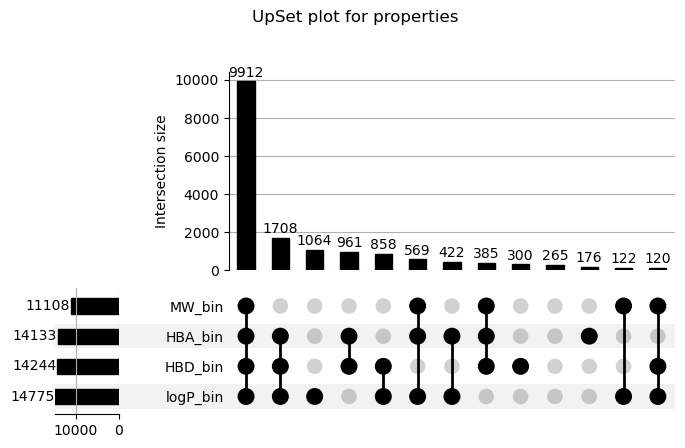

In [46]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

df[bin_cols] = df[bin_cols].fillna(0).astype(int)

# Ensure binary / boolean
df[bin_cols] = df[bin_cols].fillna(0).astype(bool)

# Create upset data (NO sort_by here)
data = from_indicators(bin_cols, df)

# Plot
plt.figure(figsize=(10, 6))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

up.plot()
plt.suptitle("UpSet plot for properties", y=1.02)
plt.show()